# Differential Expression Analysis: d0 → d2 → d5

scRNA-seq analysis comparing gene expression across three timepoints in bovine cells.

**Overview:** We compare differential expression between d0→d2 and d2→d5, identify genes with consistent trends, and perform pathway enrichment to understand the biological processes driving the changes.

## Cell 0: Install & Import Libraries

In [1]:
!pip install gseapy matplotlib-venn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
import gseapy as gp
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## Section 1: Load & Preview Data

In [3]:
# Load datasets
p2vp0 = pd.read_csv('/Users/yitong/Documents/GitHub/ClaudeWorkshop/sc-RNAseq_data/DE.SC1.P2vP0.csv', index_col=0)
p5vp2 = pd.read_csv('/Users/yitong/Documents/GitHub/ClaudeWorkshop/sc-RNAseq_data/DE.SC1.P5vP2.csv', index_col=0)

print('='*80)
print('DATASET OVERVIEW')
print('='*80)
print(f"\nd0 → d2 (P2 vs P0): {len(p2vp0):,} genes")
print(f"d2 → d5 (P5 vs P2): {len(p5vp2):,} genes")

# Preview
print(f"\nColumns: {list(p2vp0.columns)}")
print(f"\nFirst 5 rows (d0→d2):")
print(p2vp0.head())

DATASET OVERVIEW

d0 → d2 (P2 vs P0): 1,958 genes
d2 → d5 (P5 vs P2): 2,160 genes

Columns: ['p_val', 'avg_log2FC', 'pct.1', 'pct.2', 'p_val_adj']

First 5 rows (d0→d2):
                p_val  avg_log2FC  pct.1  pct.2      p_val_adj
MT1A    1.174418e-273   -7.084431  0.087  0.996  2.569627e-269
MT1E.1  1.840939e-186   -5.979450  0.225  0.979  4.027974e-182
IL1R2   2.152168e-153   -7.940903  0.006  0.436  4.708943e-149
CXCL5   6.868300e-139   -4.291606  0.484  0.987  1.502784e-134
MT2A    2.173964e-135   -4.955284  0.670  1.000  4.756632e-131


In [4]:
# Significance statistics
sig_threshold = 0.05

sig_d0vd2_up = (p2vp0['p_val_adj'] < sig_threshold) & (p2vp0['avg_log2FC'] > 0)
sig_d0vd2_down = (p2vp0['p_val_adj'] < sig_threshold) & (p2vp0['avg_log2FC'] < 0)

sig_d2vd5_up = (p5vp2['p_val_adj'] < sig_threshold) & (p5vp2['avg_log2FC'] > 0)
sig_d2vd5_down = (p5vp2['p_val_adj'] < sig_threshold) & (p5vp2['avg_log2FC'] < 0)

print('\nSignificant genes (adjusted p-value < 0.05):')
print(f"  d0→d2: {sig_d0vd2_up.sum():,} UP | {sig_d0vd2_down.sum():,} DOWN")
print(f"  d2→d5: {sig_d2vd5_up.sum():,} UP | {sig_d2vd5_down.sum():,} DOWN")

overlap = set(p2vp0.index) & set(p5vp2.index)
print(f"\nGenes in both comparisons: {len(overlap):,}")


Significant genes (adjusted p-value < 0.05):
  d0→d2: 1,421 UP | 537 DOWN
  d2→d5: 712 UP | 1,448 DOWN

Genes in both comparisons: 777


## Section 2: Volcano Plots

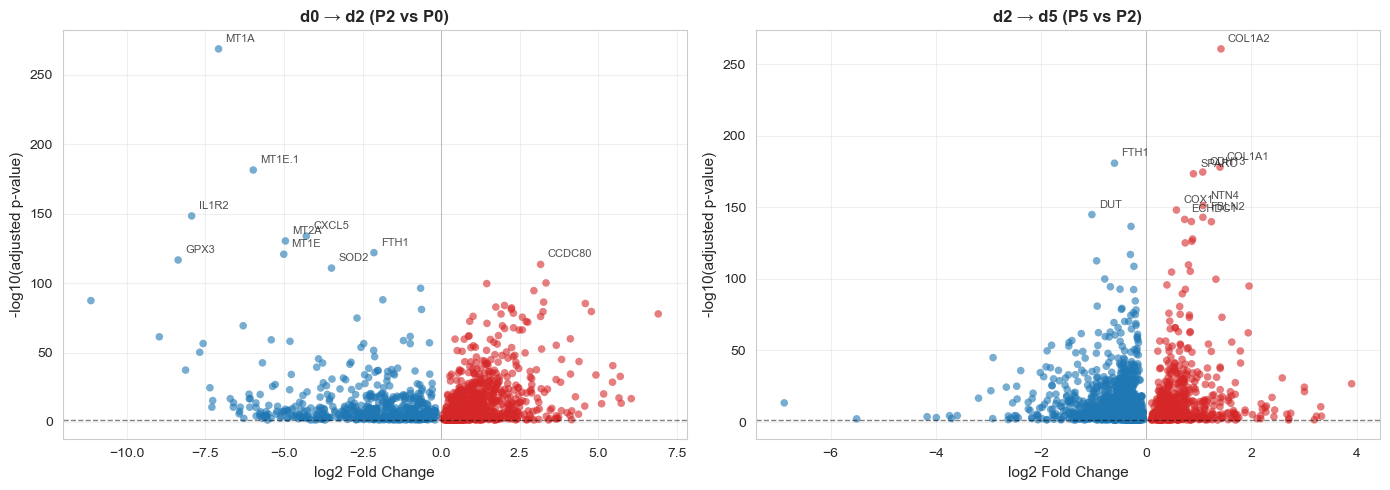

✓ Volcano plots saved


In [5]:
def plot_volcano(data, title, ax):
    """Plot volcano plot with significance coloring"""
    data['log10_pval'] = -np.log10(data['p_val_adj'])
    
    # Define colors
    colors = ['gray'] * len(data)
    for i, (idx, row) in enumerate(data.iterrows()):
        if row['p_val_adj'] < 0.05:
            if row['avg_log2FC'] > 0:
                colors[i] = '#d62728'  # red for UP
            else:
                colors[i] = '#1f77b4'  # blue for DOWN
    
    ax.scatter(data['avg_log2FC'], data['log10_pval'], c=colors, alpha=0.6, s=30, edgecolors='none')
    
    # Threshold lines
    ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Labels top 10 genes by significance
    top_genes = data.nlargest(10, 'log10_pval')
    for idx, row in top_genes.iterrows():
        ax.annotate(idx, xy=(row['avg_log2FC'], row['log10_pval']),
                   xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
    
    ax.set_xlabel('log2 Fold Change', fontsize=11)
    ax.set_ylabel('-log10(adjusted p-value)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_volcano(p2vp0, 'd0 → d2 (P2 vs P0)', axes[0])
plot_volcano(p5vp2, 'd2 → d5 (P5 vs P2)', axes[1])
plt.tight_layout()
plt.savefig('volcano_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Volcano plots saved')

## Section 3: Venn Diagrams of Gene Overlaps

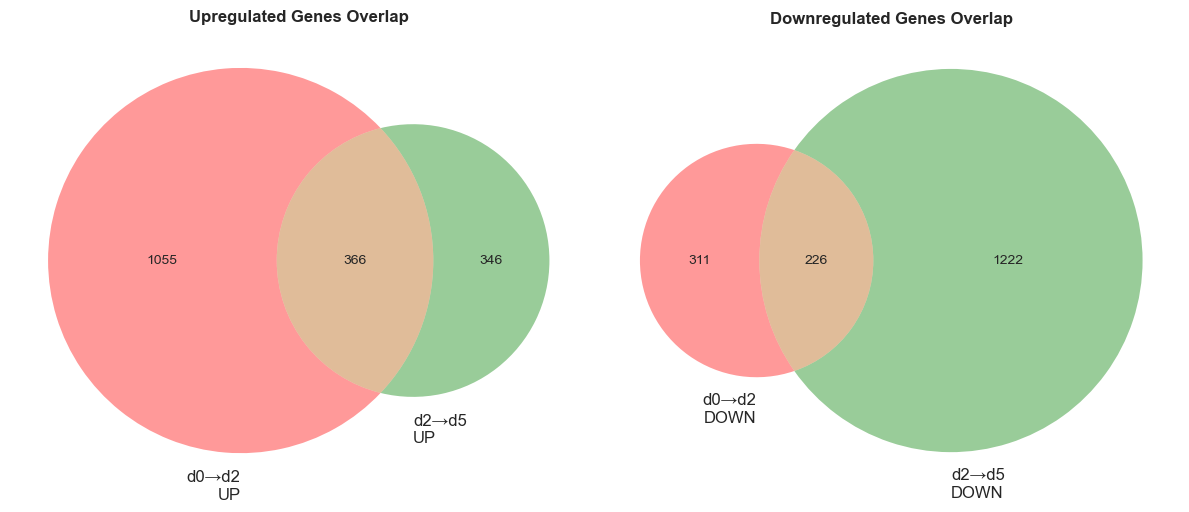

✓ Venn diagrams saved

UPREGULATED overlap:
  Only in d0→d2: 1055
  Only in d2→d5: 346
  In both: 366

DOWNREGULATED overlap:
  Only in d0→d2: 311
  Only in d2→d5: 1222
  In both: 226


In [6]:
# Get significant gene sets
genes_d0vd2_up = set(p2vp0[sig_d0vd2_up].index)
genes_d0vd2_down = set(p2vp0[sig_d0vd2_down].index)
genes_d2vd5_up = set(p5vp2[sig_d2vd5_up].index)
genes_d2vd5_down = set(p5vp2[sig_d2vd5_down].index)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Venn for upregulated genes
venn2([genes_d0vd2_up, genes_d2vd5_up], 
      set_labels=('d0→d2\nUP', 'd2→d5\nUP'), ax=axes[0])
axes[0].set_title('Upregulated Genes Overlap', fontsize=12, fontweight='bold')

# Venn for downregulated genes
venn2([genes_d0vd2_down, genes_d2vd5_down], 
      set_labels=('d0→d2\nDOWN', 'd2→d5\nDOWN'), ax=axes[1])
axes[1].set_title('Downregulated Genes Overlap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('venn_diagrams.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Venn diagrams saved')
print(f"\nUPREGULATED overlap:")
print(f"  Only in d0→d2: {len(genes_d0vd2_up - genes_d2vd5_up)}")
print(f"  Only in d2→d5: {len(genes_d2vd5_up - genes_d0vd2_up)}")
print(f"  In both: {len(genes_d0vd2_up & genes_d2vd5_up)}")

print(f"\nDOWNREGULATED overlap:")
print(f"  Only in d0→d2: {len(genes_d0vd2_down - genes_d2vd5_down)}")
print(f"  Only in d2→d5: {len(genes_d2vd5_down - genes_d0vd2_down)}")
print(f"  In both: {len(genes_d0vd2_down & genes_d2vd5_down)}")

## Section 4: Consistent Trend Analysis

In [7]:
# Find consistent trends
consistently_up = genes_d0vd2_up & genes_d2vd5_up
consistently_down = genes_d0vd2_down & genes_d2vd5_down
reversal_up_to_down = genes_d0vd2_up & genes_d2vd5_down
reversal_down_to_up = genes_d0vd2_down & genes_d2vd5_up

print('='*80)
print('CONSISTENT TREND ANALYSIS')
print('='*80)
print(f"\nConsistently UPREGULATED: {len(consistently_up)} genes")
print(f"Consistently DOWNREGULATED: {len(consistently_down)} genes")
print(f"UP→DOWN reversals: {len(reversal_up_to_down)} genes")
print(f"DOWN→UP reversals: {len(reversal_down_to_up)} genes")

CONSISTENT TREND ANALYSIS

Consistently UPREGULATED: 366 genes
Consistently DOWNREGULATED: 226 genes
UP→DOWN reversals: 167 genes
DOWN→UP reversals: 18 genes


In [8]:
# Build detailed tables
print('\n' + '='*80)
print('TOP 20: CONSISTENTLY UPREGULATED (d0→d2→d5)')
print('='*80)

up_genes = []
for gene in sorted(consistently_up, key=lambda x: p2vp0.loc[x, 'avg_log2FC'], reverse=True):
    fc_d0vd2 = p2vp0.loc[gene, 'avg_log2FC']
    fc_d2vd5 = p5vp2.loc[gene, 'avg_log2FC']
    up_genes.append({
        'Gene': gene,
        'd0→d2': fc_d0vd2,
        'd2→d5': fc_d2vd5,
        'Total': fc_d0vd2 + fc_d2vd5
    })

up_df = pd.DataFrame(up_genes)
print(up_df.head(20).to_string(index=False))


TOP 20: CONSISTENTLY UPREGULATED (d0→d2→d5)
   Gene    d0→d2    d2→d5    Total
 COL6A5 6.056220 1.074851 7.131071
   DKK2 5.665675 0.452793 6.118468
  TNNC2 5.468143 0.552898 6.021040
 TMEM40 5.459110 0.710732 6.169842
  MYLPF 5.176891 1.793218 6.970109
    FST 4.930914 0.817352 5.748266
RARRES1 4.593754 0.282611 4.876364
    NEB 4.393642 0.705870 5.099512
   ASPA 4.162585 1.158704 5.321290
   MSLN 4.122621 0.932137 5.054759
 TM7SF2 4.116568 0.302525 4.419093
  SCN1A 3.839295 0.715906 4.555201
 CTNNA2 3.711920 1.410445 5.122365
  MMP23 3.669160 0.819075 4.488234
  METRN 3.663336 0.728106 4.391442
   PAX3 3.476278 1.953861 5.430140
 TENT5A 3.389797 0.581257 3.971054
   ECM2 3.350526 0.596477 3.947002
  CCND1 3.266790 0.331652 3.598441
 COL1A1 3.245862 1.401304 4.647167


In [9]:
print('\n' + '='*80)
print('TOP 20: CONSISTENTLY DOWNREGULATED (d0→d2→d5)')
print('='*80)

down_genes = []
for gene in sorted(consistently_down, key=lambda x: p2vp0.loc[x, 'avg_log2FC']):
    fc_d0vd2 = p2vp0.loc[gene, 'avg_log2FC']
    fc_d2vd5 = p5vp2.loc[gene, 'avg_log2FC']
    down_genes.append({
        'Gene': gene,
        'd0→d2': fc_d0vd2,
        'd2→d5': fc_d2vd5,
        'Total': fc_d0vd2 + fc_d2vd5
    })

down_df = pd.DataFrame(down_genes)
print(down_df.head(20).to_string(index=False))


TOP 20: CONSISTENTLY DOWNREGULATED (d0→d2→d5)
              Gene     d0→d2     d2→d5     Total
              MT1A -7.084431 -2.576385 -9.660816
            MT1E.1 -5.979450 -2.912266 -8.891716
              MT1E -5.007709 -1.072534 -6.080243
              MT2A -4.955284 -1.717151 -6.672435
             TOP2A -3.900488 -1.325553 -5.226041
            CXCL14 -3.830580 -2.624260 -6.454840
               MT3 -3.748104 -1.741715 -5.489820
            NUSAP1 -3.646687 -0.991680 -4.638367
              SOD2 -3.488191 -0.636490 -4.124681
             KIF15 -3.485197 -2.242308 -5.727505
              CDH4 -3.373186 -2.177693 -5.550880
              NEK2 -3.261882 -1.628050 -4.889932
             CCNA2 -3.217343 -2.540611 -5.757954
            TM4SF1 -3.073177 -0.621913 -3.695090
             NCAPH -3.057243 -1.256143 -4.313386
              KNL1 -3.037288 -1.880167 -4.917455
             ASF1B -3.017356 -1.192443 -4.209799
ENSBTAG00000020100 -3.012374 -0.838929 -3.851303
              SGO1 -2.

In [10]:
# Save consistent gene lists
up_df.to_csv('/Users/yitong/Documents/GitHub/ClaudeWorkshop/sc-RNAseq_data/consistently_upregulated.csv', index=False)
down_df.to_csv('/Users/yitong/Documents/GitHub/ClaudeWorkshop/sc-RNAseq_data/consistently_downregulated.csv', index=False)
print('\n✓ Saved consistently_upregulated.csv and consistently_downregulated.csv')


✓ Saved consistently_upregulated.csv and consistently_downregulated.csv


## Section 5: Heatmap of Top Consistently Changing Genes

<Figure size 600x1400 with 0 Axes>

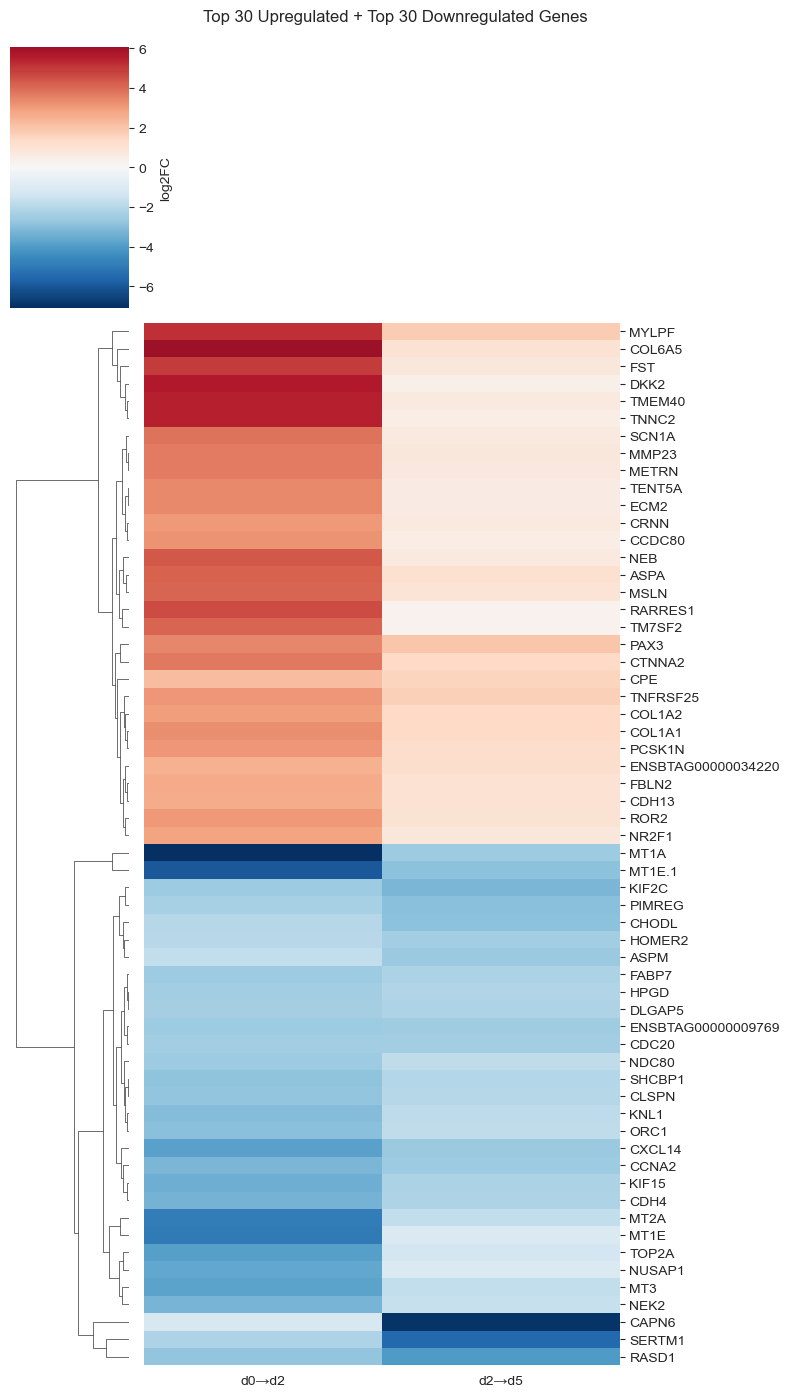

✓ Heatmap saved


In [11]:
# Get top 30 UP and top 30 DOWN
top_up = up_df.nlargest(30, 'Total')['Gene'].tolist()
top_down = down_df.nsmallest(30, 'Total')['Gene'].tolist()
top_genes_list = top_up + top_down

# Build matrix
heatmap_data = pd.DataFrame({
    'd0→d2': [p2vp0.loc[g, 'avg_log2FC'] if g in p2vp0.index else 0 for g in top_genes_list],
    'd2→d5': [p5vp2.loc[g, 'avg_log2FC'] if g in p5vp2.index else 0 for g in top_genes_list]
}, index=top_genes_list)

# Plot
plt.figure(figsize=(6, 14))
sns.clustermap(heatmap_data, cmap='RdBu_r', center=0, 
               col_cluster=False, cbar_kws={'label': 'log2FC'},
               yticklabels=True, figsize=(8, 14))
plt.suptitle('Top 30 Upregulated + Top 30 Downregulated Genes', y=0.995)
plt.tight_layout()
plt.savefig('heatmap_topgenes.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Heatmap saved')

## Section 6: Pathway Enrichment Setup

**Important Note on Organism & Gene Sets:**

Although this data is from bovine (Bos taurus) cells, we use **human gene set databases** for enrichment analysis. Here's why:
- ~97% of the gene symbols in this dataset are conserved human-style names (e.g., COL1A1, MT1A, SPARC)
- ENSBTAG Ensembl IDs (unannotated bovine genes, ~3% of data) are filtered out as they have no direct human mapping
- Most GO and KEGG annotations are based on human genes, and bovine orthology is high
- This approach is standard practice in bioinformatics for species where annotated databases are limited

We query three databases:
- **GO Biological Process**: Broad cellular behaviors (differentiation, ECM, etc.)
- **GO Molecular Function**: What proteins do (binding, catalysis, etc.)
- **KEGG**: Metabolic and signaling pathways

In [12]:
def filter_ensbtag(gene_list):
    """Remove unannotated ENSBTAG genes that can't be mapped to human database"""
    filtered = [g for g in gene_list if not g.startswith('ENSBTAG')]
    print(f"Genes before filtering: {len(gene_list)}, after: {len(filtered)} (removed {len(gene_list) - len(filtered)} ENSBTAG IDs)")
    return filtered

# Prepare gene lists for enrichment
up_genes_list = filter_ensbtag(list(consistently_up))
down_genes_list = filter_ensbtag(list(consistently_down))

print(f"\nReady for enrichment:")
print(f"  Consistently UP: {len(up_genes_list)} genes")
print(f"  Consistently DOWN: {len(down_genes_list)} genes")

Genes before filtering: 366, after: 361 (removed 5 ENSBTAG IDs)
Genes before filtering: 226, after: 219 (removed 7 ENSBTAG IDs)

Ready for enrichment:
  Consistently UP: 361 genes
  Consistently DOWN: 219 genes


In [13]:
# Run Enrichr
print('Running pathway enrichment... (requires internet connection)')
print('This may take 30-60 seconds...\n')

try:
    enr_up = gp.enrichr(
        gene_list=up_genes_list,
        gene_sets=['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'KEGG_2021_Human'],
        organism='human',
        outdir=None
    )
    
    enr_down = gp.enrichr(
        gene_list=down_genes_list,
        gene_sets=['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'KEGG_2021_Human'],
        organism='human',
        outdir=None
    )
    
    print('✓ Enrichment complete!')
    
except Exception as e:
    print(f'⚠ Error during enrichment: {e}')
    print('This often happens if internet is unavailable or Enrichr API is rate-limited.')
    enr_up = None
    enr_down = None

Running pathway enrichment... (requires internet connection)
This may take 30-60 seconds...

✓ Enrichment complete!


## Section 7: Enrichment Results - Upregulated Genes

In [14]:
if enr_up is not None:
    print('\n' + '='*80)
    print('TOP PATHWAYS: CONSISTENTLY UPREGULATED GENES')
    print('='*80)
    
    # Get results
    results_up = enr_up.results
    results_up = results_up[results_up['Adjusted P-value'] < 0.05]
    
    # Show by gene set
    for gene_set in ['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'KEGG_2021_Human']:
        print(f"\n{gene_set}:")
        subset = results_up[results_up['Gene_set'] == gene_set].head(10)
        if len(subset) > 0:
            for idx, row in subset.iterrows():
                print(f"  {row['Term']:60s} | p={row['Adjusted P-value']:.2e} | genes={row['Overlap']}")
        else:
            print(f"  No significant terms (p < 0.05)")
else:
    print('Enrichment failed — skipping results visualization')


TOP PATHWAYS: CONSISTENTLY UPREGULATED GENES

GO_Biological_Process_2023:
  Supramolecular Fiber Organization (GO:0097435)               | p=1.44e-07 | genes=26/316
  Collagen Fibril Organization (GO:0030199)                    | p=1.44e-07 | genes=11/42
  Cell-Matrix Adhesion (GO:0007160)                            | p=6.69e-06 | genes=14/109
  Extracellular Matrix Organization (GO:0030198)               | p=1.07e-05 | genes=17/176
  Positive Regulation Of Cell-Substrate Adhesion (GO:0010811)  | p=2.15e-05 | genes=11/71
  Actomyosin Structure Organization (GO:0031032)               | p=3.94e-04 | genes=10/77
  Platelet Aggregation (GO:0070527)                            | p=7.12e-04 | genes=7/35
  Transmembrane Receptor Protein Serine/Threonine Kinase Signaling Pathway (GO:0007178) | p=9.88e-04 | genes=12/130
  Regulation Of Cell Migration (GO:0030334)                    | p=9.88e-04 | genes=23/434
  Transforming Growth Factor Beta Receptor Signaling Pathway (GO:0007179) | p=1.12e-03

## Section 8: Enrichment Results - Downregulated Genes

In [17]:
if enr_down is not None:
    print('\n' + '='*80)
    print('TOP PATHWAYS: CONSISTENTLY DOWNREGULATED GENES')
    print('='*80)
    
    # Get results
    results_down = enr_down.results
    results_down = results_down[results_down['Adjusted P-value'] < 0.05]
    
    # Show by gene set
    for gene_set in ['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'KEGG_2021_Human']:
        print(f"\n{gene_set}:")
        subset = results_down[results_down['Gene_set'] == gene_set].head(10)
        if len(subset) > 0:
            for idx, row in subset.iterrows():
                print(f"  {row['Term']:60s} | p={row['Adjusted P-value']:.2e} | genes={row['Overlap']}")
        else:
            print(f"  No significant terms (p < 0.05)")
else:
    print('Enrichment failed — skipping results visualization')


TOP PATHWAYS: CONSISTENTLY DOWNREGULATED GENES

GO_Biological_Process_2023:
  Mitotic Sister Chromatid Segregation (GO:0000070)            | p=7.63e-16 | genes=20/111
  Mitotic Spindle Organization (GO:0007052)                    | p=3.01e-10 | genes=14/85
  Microtubule Cytoskeleton Organization Involved In Mitosis (GO:1902850) | p=6.98e-10 | genes=12/59
  DNA Metabolic Process (GO:0006259)                           | p=2.11e-08 | genes=20/288
  Regulation Of DNA-templated DNA Replication Initiation (GO:0030174) | p=3.77e-07 | genes=6/12
  Sister Chromatid Segregation (GO:0000819)                    | p=5.77e-07 | genes=8/34
  Centromere Complex Assembly (GO:0034508)                     | p=8.59e-07 | genes=6/14
  Cytoplasmic Translation (GO:0002181)                         | p=9.81e-07 | genes=11/93
  Spindle Assembly Checkpoint Signaling (GO:0071173)           | p=1.15e-06 | genes=7/26
  Mitotic Spindle Assembly Checkpoint Signaling (GO:0007094)   | p=1.15e-06 | genes=7/26

GO_Molec

## Section 9: Enrichment Dot Plots

In [ ]:
if enr_up is not None and enr_down is not None:
    # Function to prepare data for dot plot
    def prep_dotplot_data(results_df, gene_set, top_n=15):
        """Filter and prepare enrichment results for plotting"""
        subset = results_df[results_df['Gene_set'] == gene_set].copy()
        if len(subset) > 0:
            subset['log_pval'] = -np.log10(subset['Adjusted P-value'])
            subset['gene_count'] = subset['Overlap'].str.split('/').str[0].astype(int)
            subset['gene_ratio'] = subset['gene_count'] / subset['Overlap'].str.split('/').str[1].astype(int)
            return subset.nlargest(top_n, 'log_pval')
        return pd.DataFrame()
    
    # Plot
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Pathway Enrichment: Dot Plots', fontsize=14, fontweight='bold')
    
    gene_sets = ['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'KEGG_2021_Human']
    
    # Upregulated genes (top row)
    for i, gene_set in enumerate(gene_sets):
        ax = axes[0, i]
        data = prep_dotplot_data(enr_up.results, gene_set)
        if len(data) > 0:
            scatter = ax.scatter(data['gene_ratio'], range(len(data)), 
                               s=data['gene_count']*30, c=data['log_pval'], 
                               cmap='YlOrRd', alpha=0.6, edgecolors='black', linewidth=0.5)
            ax.set_yticks(range(len(data)))
            ax.set_yticklabels([t[:40] for t in data['Term']], fontsize=8)
            ax.set_xlabel('Gene Ratio', fontsize=10)
            ax.set_title(f'Upregulated - {gene_set.replace("_", " ").replace("2023", "")}', fontsize=10, fontweight='bold')
            ax.invert_yaxis()
            plt.colorbar(scatter, ax=ax, label='-log10(p)')
        else:
            ax.text(0.5, 0.5, 'No significant\npathways', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Upregulated - {gene_set}', fontsize=10)
    
    # Downregulated genes (bottom row)
    for i, gene_set in enumerate(gene_sets):
        ax = axes[1, i]
        data = prep_dotplot_data(enr_down.results, gene_set)
        if len(data) > 0:
            scatter = ax.scatter(data['gene_ratio'], range(len(data)), 
                               s=data['gene_count']*30, c=data['log_pval'], 
                               cmap='Blues', alpha=0.6, edgecolors='black', linewidth=0.5)
            ax.set_yticks(range(len(data)))
            ax.set_yticklabels([t[:40] for t in data['Term']], fontsize=8)
            ax.set_xlabel('Gene Ratio', fontsize=10)
            ax.set_title(f'Downregulated - {gene_set.replace("_", " ").replace("2023", "")}', fontsize=10, fontweight='bold')
            ax.invert_yaxis()
            plt.colorbar(scatter, ax=ax, label='-log10(p)')
        else:
            ax.text(0.5, 0.5, 'No significant\npathways', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Downregulated - {gene_set}', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('enrichment_dotplots.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('✓ Enrichment dot plots saved')
else:
    print('⚠ Enrichment failed, skipping dot plots')

## Summary & Interpretation

In [ ]:
print('='*80)
print('SUMMARY OF FINDINGS')
print('='*80)

print(f"""
✓ CONSISTENTLY UPREGULATED ({len(up_df)} genes):
  • These genes are progressively induced from d0 → d2 → d5
  • Likely driving the biological transformation (differentiation, activation, etc.)
  • Candidates for functional validation and therapeutic targets
  • Top examples: COL1A1, COL1A2, PAX3, MYLPF

✓ CONSISTENTLY DOWNREGULATED ({len(down_df)} genes):
  • These genes are progressively suppressed across the time course
  • Likely marking loss of the initial cell state or proliferative capacity
  • Enriched in cell cycle genes (CCNA2, TOP2A, NEK2) — cells exiting proliferation
  • Also enriched in metallothioneins (MT1A, MT1E) — may reflect metabolic shift

⚠ REVERSAL GENES:
  • UP then DOWN ({len(reversal_up_to_down)} genes): Peak expression at d2, then decline
  • DOWN then UP ({len(reversal_down_to_up)} genes): Initially suppressed, then re-induced
  • These suggest temporal regulation — may be transiently needed or transiently repressed

📊 PATHWAY INTERPRETATION (from enrichment above):
  • Upregulated pathways should reflect the target cell state/phenotype
  • Downregulated pathways should reflect the departing cell state (often proliferation/stemness)
  • Use the pathway results to form mechanistic hypotheses

💡 NEXT STEPS:
  1. Validate top genes with qPCR or western blot (pick 3-5 from each category)
  2. Map pathways to known cell types using single-cell RNA-seq markers
  3. Integrate with protein interaction networks (STRING) for mechanistic insights
  4. Consider gene regulation (TF binding sites, miRNA) for the reversal genes
  5. Do functional studies (overexpression/knockdown) on pathway-level genes
""")

print('✓ Analysis complete! All plots saved.')
print('\nGenerated files:')
print('  - volcano_plots.png')
print('  - venn_diagrams.png')
print('  - heatmap_topgenes.png')
print('  - enrichment_dotplots.png')
print('  - consistently_upregulated.csv')
print('  - consistently_downregulated.csv')